# **Tahap Model - Prediksi Harga Pangan**
Notebook ini bertujuan membangun model peramalan (forecasting) harga komoditas paling volatil (Cabai Merah Keriting) menggunakan algoritma SARIMAX, dengan memanfaatkan fitur cuaca dan perhitungan mundur Idul Adha.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style="whitegrid")

### **1. Data Preparation**

In [65]:
df = pd.read_csv('../datasets/clean_dataset/clean_merged_dataset.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df['Tahun'] = df['Tanggal'].dt.year

komoditas = 'Cabai Merah Besar' # BISA DIGANTI SESUAI KOMODITAS YANG INGIN DIPREDIKSI
df_model = df[df['Komoditas'] == komoditas].copy()
df_model = df_model.sort_values('Tanggal')

In [66]:
df_model['Harga_Baseline'] = df_model.groupby('Tahun')['Harga'].transform('first')

df_model['Rasio_Kenaikan'] = df_model['Harga'] / df_model['Harga_Baseline']

# Fitur prediktor
features = ['Days_to_Idul_Adha', 'Is_Idul_Adha_Week', 'PRECTOTCORR', 'T2M', 'RH2M', 'WS10M']

### **2. Splitting Data (Train vs Test)**

In [67]:
train_data = df_model[df_model['Tahun'] < 2026].copy()
test_data = df_model[df_model['Tahun'] == 2026].copy()

X_train = train_data[features]
y_train_ratio = train_data['Rasio_Kenaikan'] 

X_test = test_data[features]
y_test_harga_aktual = test_data['Harga']

### **4. Training Model**

In [68]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_ratio)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### **5.Prediksi & Evaluasi Metrik**

In [69]:
test_data['Prediksi_Rasio'] = rf_model.predict(X_test)
test_data['Prediksi_Harga'] = test_data['Prediksi_Rasio'] * test_data['Harga_Baseline']

mape = mean_absolute_percentage_error(y_test_harga_aktual, test_data['Prediksi_Harga']) * 100
print(f"MAPE: {mape:.2f}%")
mae = np.mean(np.abs(test_data['Prediksi_Harga'] - y_test_harga_aktual))
print(f"MAE: {mae:.2f}")

MAPE: 7.84%
MAE: 4961.93


### **6. Visualisasi Hasil Forecast (Interpretasi)**

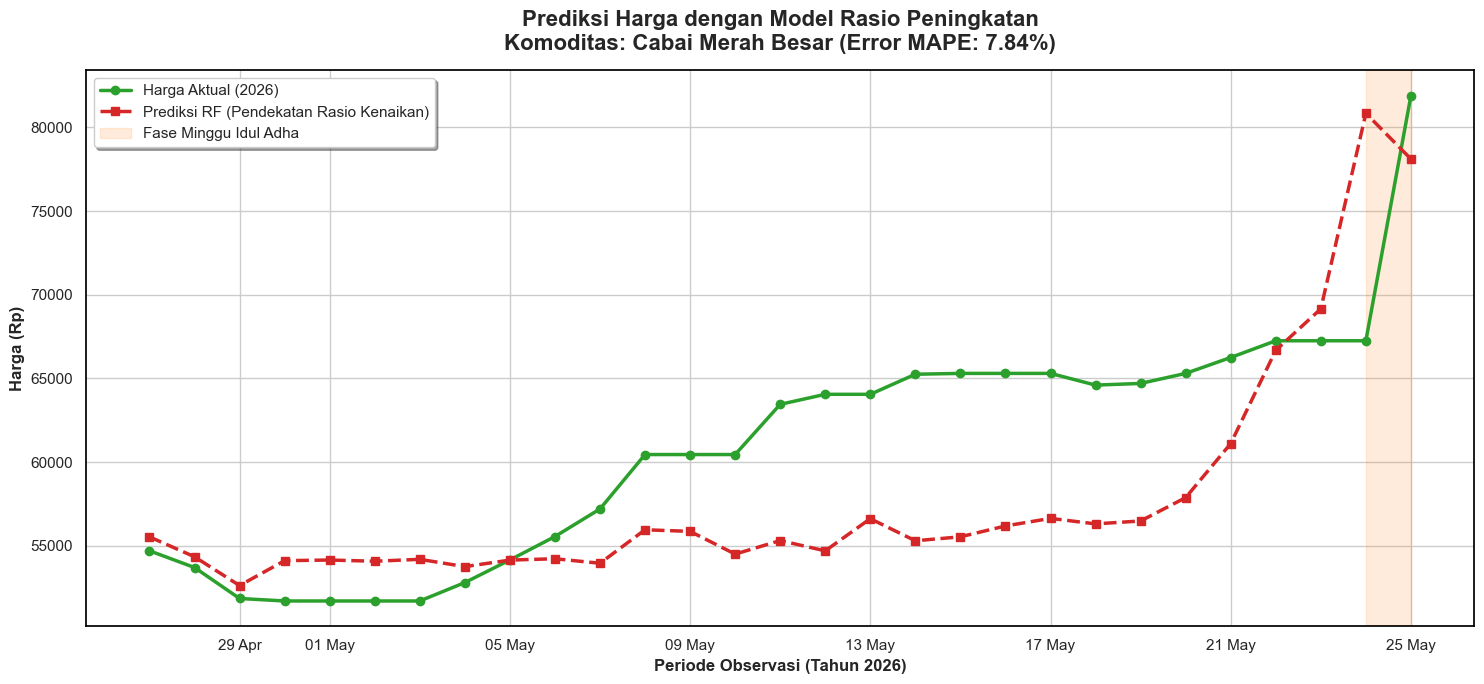

In [70]:
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black"})
plt.figure(figsize=(15, 7))

plt.plot(test_data['Tanggal'], test_data['Harga'], label='Harga Aktual (2026)', color='#2ca02c', marker='o', linewidth=2.5, markersize=6)
plt.plot(test_data['Tanggal'], test_data['Prediksi_Harga'], label='Prediksi RF (Pendekatan Rasio Kenaikan)', color='#d62728', linestyle='--', marker='s', linewidth=2.5, markersize=6)

tgl_idul_adha = test_data[test_data['Is_Idul_Adha_Week'] == 1]['Tanggal']
if not tgl_idul_adha.empty:
    plt.axvspan(tgl_idul_adha.min(), tgl_idul_adha.max(), color='#ff7f0e', alpha=0.15, label='Fase Minggu Idul Adha')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.title(f'Prediksi Harga dengan Model Rasio Peningkatan\nKomoditas: {komoditas.strip()} (Error MAPE: {mape:.2f}%)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Periode Observasi (Tahun 2026)', fontsize=12, fontweight='bold')
plt.ylabel('Harga (Rp)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()